<a href="https://colab.research.google.com/github/TMPenwell/MIS2800/blob/main/AFC_Cybersecurity_Analysis_IC_20260413.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AFC Cybersecurity Incident Analysis
**Scenario:** You are a security analyst hired by the AFC to assess cyber risk across all 16 teams.

**Dataset:** `AFC_Cybersecurity_Incidents.csv`

## Step 1 — Load the CSV into SQLite

In [2]:
import sqlite3
import csv
import matplotlib.pyplot as plt

CSV_PATH = 'AFC_Cybersecurity_Incidents.csv'

conn = sqlite3.connect(':memory:')
cursor = conn.cursor()

with open(CSV_PATH, newline='', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    headers = [h.strip() for h in reader.fieldnames]
    cols = ', '.join(f'"{h}" TEXT' for h in headers)
    cursor.execute(f'CREATE TABLE incidents ({cols})')
    for row in reader:
        vals = [row[h].strip() for h in reader.fieldnames]
        cursor.execute(f'INSERT INTO incidents VALUES ({(",".join(["?"]*len(headers)))})', vals)

conn.commit()
print('Database ready')
print('Columns:', headers)

Database ready
Columns: ['Incident ID', 'Date', 'Year', 'Team', 'Division', 'Attack Type', 'Stadium System Targeted', 'Defense Mechanism Used', 'Severity Level', 'Financial Loss (in Thousands $)', 'Fan Records Exposed', 'Incident Resolution Time (in Hours)', 'Game Day Incident']


## Step 2 — Preview the data

In [3]:
cursor.execute('SELECT * FROM incidents LIMIT 5')
rows = cursor.fetchall()
for row in rows:
    print(row)

('AFC-1025', '2019-01-09', '2019', 'Los Angeles Chargers', 'AFC West', 'Phishing', 'Point of Sale', 'Firewall', 'Low', '788.98', '74521', '22.4', 'Yes')
('AFC-1234', '2019-01-15', '2019', 'Denver Broncos', 'AFC West', 'SQL Injection', 'Fan Mobile App', 'Incident Response Team', 'Critical', '1548.93', '362856', '8.9', 'No')
('AFC-1002', '2019-01-27', '2019', 'Kansas City Chiefs', 'AFC West', 'Phishing', 'Point of Sale', 'Data Encryption', 'Medium', '619.11', '46853', '34.7', 'Yes')
('AFC-1140', '2019-02-01', '2019', 'Cleveland Browns', 'AFC North', 'Phishing', 'Stadium WiFi', 'Intrusion Detection System', 'Medium', '423.04', '117893', '8.8', 'Yes')
('AFC-1024', '2019-03-02', '2019', 'New England Patriots', 'AFC East', 'Insider Threat', 'Broadcast System', 'Firewall', 'Low', '2913.19', '267861', '5.7', 'Yes')


---
## Report 1 — Team Financial Exposure
**Question:** Which AFC teams suffered the highest total financial losses from cyber incidents?

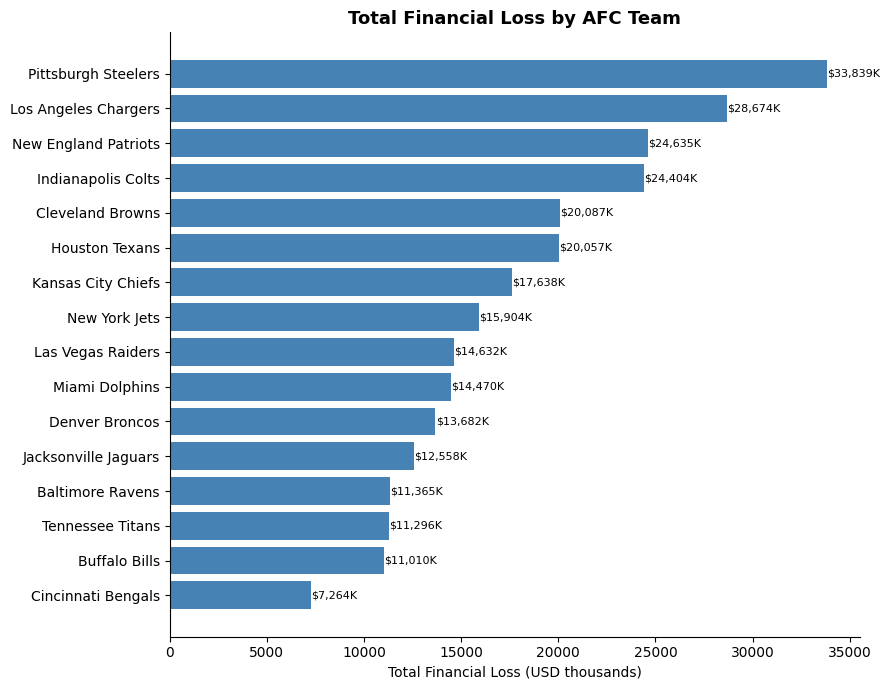

In [4]:
cursor.execute("""
    SELECT
        "Team",
        ROUND(SUM(CAST("Financial Loss (in Thousands $)" AS REAL)), 1) AS total_loss
    FROM incidents
    GROUP BY "Team"
    ORDER BY total_loss ASC
""")

rows = cursor.fetchall()
labels = [row[0] for row in rows]
values = [row[1] for row in rows]

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(labels, values, color='steelblue', edgecolor='none')

for bar in bars:
    w = bar.get_width()
    ax.text(w + 10, bar.get_y() + bar.get_height() / 2,
            f'${w:,.0f}K', va='center', fontsize=8)

ax.set_title('Total Financial Loss by AFC Team', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Financial Loss (USD thousands)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('report1_financial_exposure.png', bbox_inches='tight')
plt.show()

---
## Report 2 — Fan Data Breach Report
**Question:** Which attack types exposed the most fan records across AFC teams?

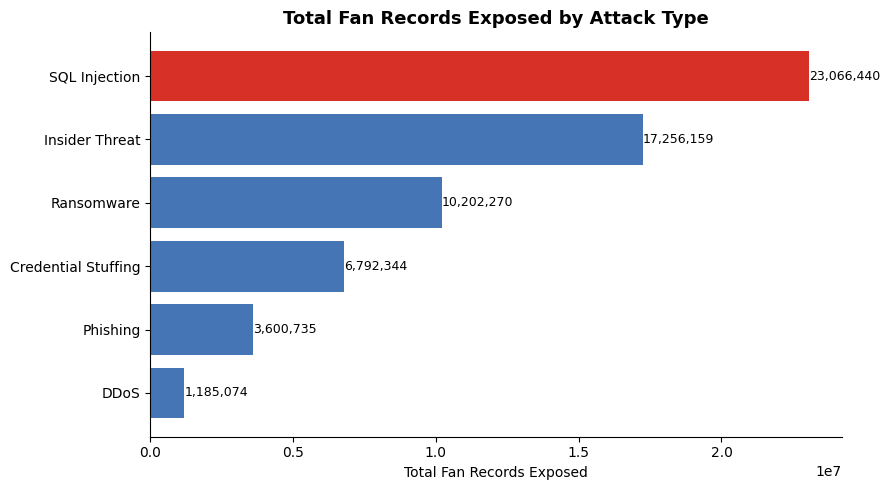

In [5]:
cursor.execute("""
    SELECT
        "Attack Type",
        SUM(CAST("Fan Records Exposed" AS INTEGER)) AS total_records
    FROM incidents
    GROUP BY "Attack Type"
    ORDER BY total_records ASC
""")

rows = cursor.fetchall()
labels = [row[0] for row in rows]
values = [row[1] for row in rows]

colors = ['#d73027' if v == max(values) else '#4575b4' for v in values]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(labels, values, color=colors, edgecolor='none')

for bar in bars:
    w = bar.get_width()
    ax.text(w + 1000, bar.get_y() + bar.get_height() / 2,
            f'{w:,.0f}', va='center', fontsize=9)

ax.set_title('Total Fan Records Exposed by Attack Type', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Fan Records Exposed')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('report2_fan_breach.png', bbox_inches='tight')
plt.show()

---
## Report 3 — Game Day Threat Report
**Question:** Which stadium systems take the longest to resolve when attacked?

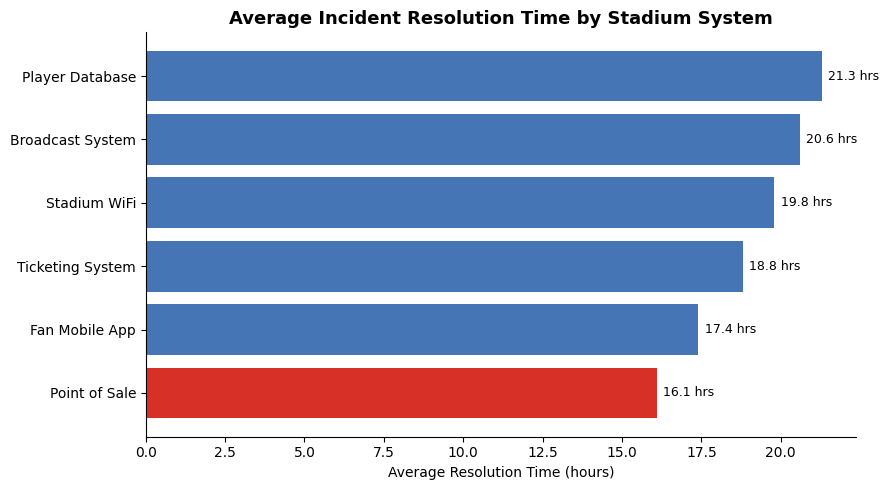

In [9]:
cursor.execute("""
    SELECT
        "Stadium System Targeted",
        ROUND(AVG(CAST("Incident Resolution Time (in Hours)" AS REAL)), 1) AS avg_hours
    FROM incidents
    GROUP BY "Stadium System Targeted"
    ORDER BY avg_hours DESC
""")

# 🧠🧠🧠🧠🧠
# The snytax below is to display the chart rows us the data in one order. We flipped it with [::-1]
# to make the chart look better. We can flip the colors by removing the [::-1].
# this can change the chart's story


rows = cursor.fetchall()
labels = [row[0] for row in rows][::-1]
values = [row[1] for row in rows][::-1]
# labels = [row[0] for row in rows]
# values = [row[1] for row in rows]

# ❓❓❓❓❓❓❓ DISCUSSION ❓❓❓❓❓❓❓
# What differences does it make for the different values to have a red bar?
# Which bar would you recommend being red and why?


colors = ['#d73027' if v == max(values) else '#4575b4' for v in values]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(labels, values, color=colors[::-1], edgecolor='none')

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.2, bar.get_y() + bar.get_height() / 2,
            f'{w:.1f} hrs', va='center', fontsize=9)

ax.set_title('Average Incident Resolution Time by Stadium System', fontsize=13, fontweight='bold')
ax.set_xlabel('Average Resolution Time (hours)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('report3_gameday_threat.png', bbox_inches='tight')
plt.show()

---
## Dashboard — All three reports

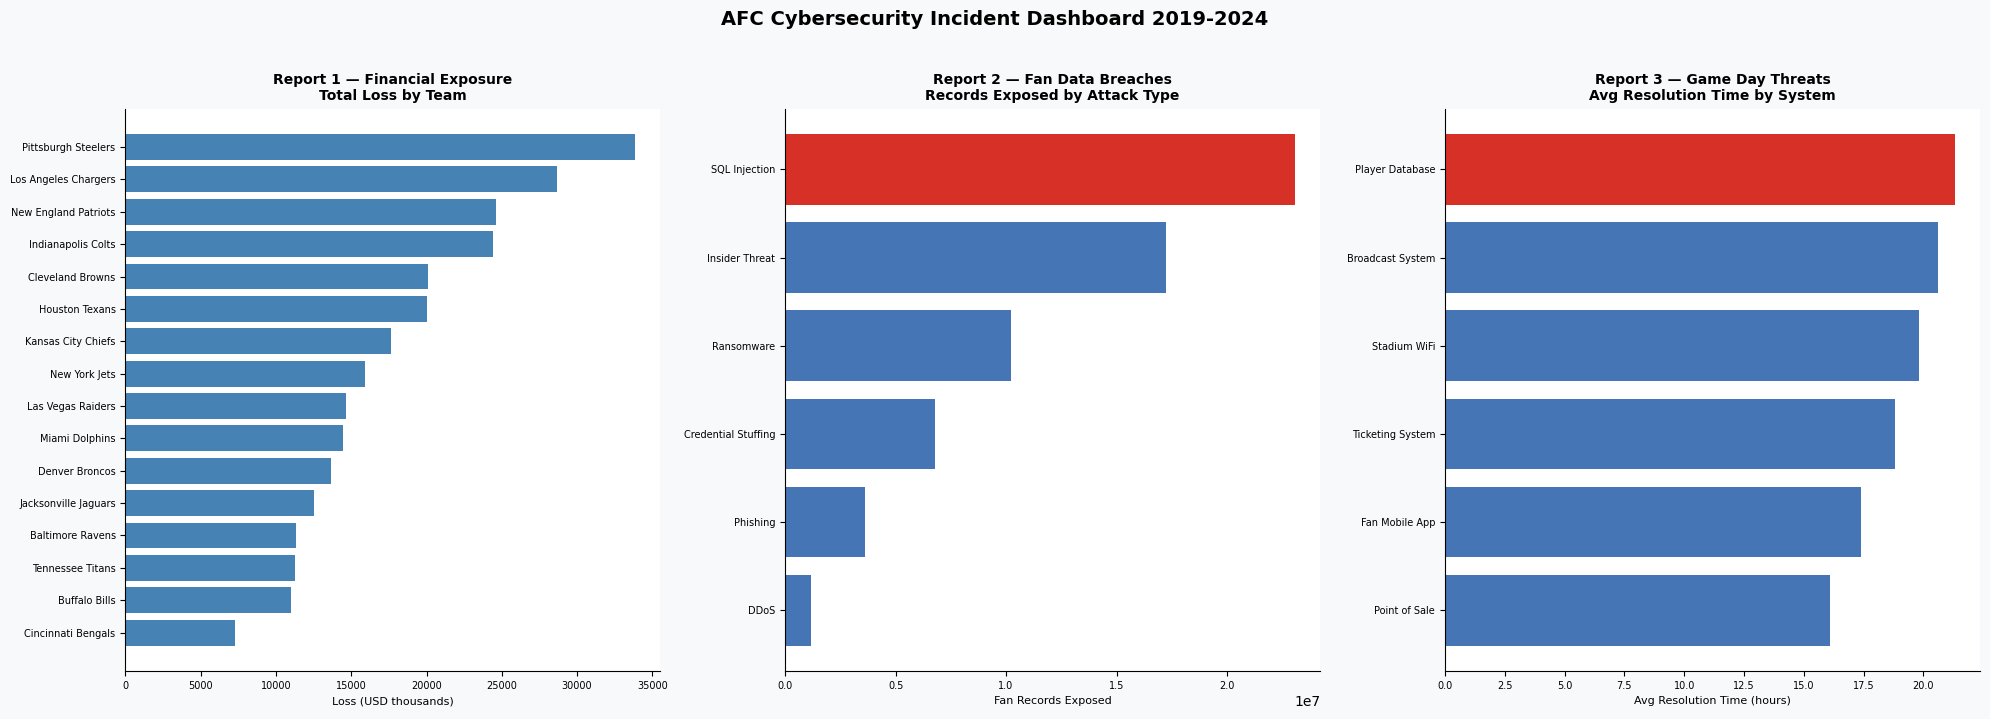

Saved: afc_dashboard.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.patch.set_facecolor('#F8F9FA')

# ── Report 1 ─────────────────────────────────────────────────────────────
cursor.execute("""
    SELECT "Team",
           ROUND(SUM(CAST("Financial Loss (in Thousands $)" AS REAL)), 1)
    FROM incidents GROUP BY "Team"
    ORDER BY 2 ASC
""")
r = cursor.fetchall()
axes[0].barh([x[0] for x in r], [x[1] for x in r], color='steelblue', edgecolor='none')
axes[0].set_title('Report 1 — Financial Exposure\nTotal Loss by Team', fontweight='bold', fontsize=10)
axes[0].set_xlabel('Loss (USD thousands)', fontsize=8)
axes[0].tick_params(labelsize=7)
axes[0].spines[['top', 'right']].set_visible(False)

# ── Report 2 ─────────────────────────────────────────────────────────────
cursor.execute("""
    SELECT "Attack Type",
           SUM(CAST("Fan Records Exposed" AS INTEGER))
    FROM incidents GROUP BY "Attack Type"
    ORDER BY 2 ASC
""")
r = cursor.fetchall()
vals = [x[1] for x in r]
colors = ['#d73027' if v == max(vals) else '#4575b4' for v in vals]
axes[1].barh([x[0] for x in r], vals, color=colors, edgecolor='none')
axes[1].set_title('Report 2 — Fan Data Breaches\nRecords Exposed by Attack Type', fontweight='bold', fontsize=10)
axes[1].set_xlabel('Fan Records Exposed', fontsize=8)
axes[1].tick_params(labelsize=7)
axes[1].spines[['top', 'right']].set_visible(False)

# ── Report 3 ─────────────────────────────────────────────────────────────
cursor.execute("""
    SELECT "Stadium System Targeted",
           ROUND(AVG(CAST("Incident Resolution Time (in Hours)" AS REAL)), 1)
    FROM incidents GROUP BY "Stadium System Targeted"
    ORDER BY 2 ASC
""")
r = cursor.fetchall()
vals = [x[1] for x in r]
colors = ['#d73027' if v == max(vals) else '#4575b4' for v in vals]
axes[2].barh([x[0] for x in r], vals, color=colors, edgecolor='none')
axes[2].set_title('Report 3 — Game Day Threats\nAvg Resolution Time by System', fontweight='bold', fontsize=10)
axes[2].set_xlabel('Avg Resolution Time (hours)', fontsize=8)
axes[2].tick_params(labelsize=7)
axes[2].spines[['top', 'right']].set_visible(False)

fig.suptitle('AFC Cybersecurity Incident Dashboard 2019-2024',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('afc_dashboard.png', bbox_inches='tight', facecolor='#F8F9FA')
plt.show()
print('Saved: afc_dashboard.png')